## **Project: Spotify User Preferences - Linear Regression**

### **Why This Project?**

Music streaming platforms like **Spotify** rely heavily on understanding user preferences to drive recommendations and engagement. In this project, I explore how **song-level audio features** — such as **valence**, **energy**, and **danceability** — can be used to model and predict a continuous **User Preference**, representing a user's musical taste profile. This provides insight into how different track characteristics influence individual listening patterns.

### **Problem Statement**

The goal of this project is to build a simple **linear regression** model that predicts a continuous **User Score** based on the audio features of songs in a user's listening history. The **User Score** reflects the degree to which a user's music preferences align with specific **emotional** and **energetic** qualities of tracks. This project demonstrates how **regression techniques** can be applied to **real-world data** to better understand user behavior.

### **Summary**

I chose this topic because it offers an interesting **real-world application of regression**, working with **continuous music feature data** to analyze and predict **user preferences** in a domain with **real business impact** and **personal relevance**.  
This is a **regression problem** because I am predicting a **continuous UserScore** based on **musical features**. If I wanted to group users into predefined categories, then **classification** would be appropriate, but here I want to model the **degree of preference numerically**.

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import chart_studio.plotly as py
import cufflinks as cf 

In [3]:
df = pd.read_csv('spotify_processed.csv')
df.head()

,track_name,valence,energy,danceability,acousticness,instrumentalness,user_preference
0,"Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj",0.118,0.339,0.743,0.005820,0.000,6.92
1,BAND DRUM (feat. A$AP Rocky),0.371,0.557,0.846,0.024400,0.000,7.99
2,Radio Silence,0.382,0.723,0.603,0.025000,0.000,7.24
3,Lactose,0.641,0.579,0.800,0.029400,0.912,6.69
4,Same - Original mix,0.928,0.792,0.783,0.000035,0.878,7.27




👉 `df.iloc[:, :-1]` → returns **all rows** and **all columns except the last one** → used for `X_train`.

👉 `df.iloc[:, -1]` → returns **all rows** and **only the last column** → used for `y_train`.


In [6]:
x_train = df.iloc[:,:-1]
y_train = df.iloc[:,-1]
print("Shape of X_train:- ",x_train.shape,"Shape of y_train:- ",y_train.shape)

Shape of X_train:-  (9999, 6) Shape of y_train:-  (9999,)


In [7]:
print("Type of X_train:- ",type(x_train),"Type of y_train:- ",type(y_train))
print("First 5 elements of X_train:- \n",x_train.head())
print("First 5 elements of y_train:- \n",y_train.head())

Type of X_train:-  <class 'pandas.core.frame.DataFrame'> Type of y_train:-  <class 'pandas.core.series.Series'>
First 5 elements of X_train:- 
                                        track_name  valence  energy  \
0  Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj    0.118   0.339   
1                    BAND DRUM (feat. A$AP Rocky)    0.371   0.557   
2                                   Radio Silence    0.382   0.723   
3                                         Lactose    0.641   0.579   
4                             Same - Original mix    0.928   0.792   

   danceability  acousticness  instrumentalness  
0         0.743      0.005820             0.000  
1         0.846      0.024400             0.000  
2         0.603      0.025000             0.000  
3         0.800      0.029400             0.912  
4         0.783      0.000035             0.878  
First 5 elements of y_train:- 
 0    6.92
1    7.99
2    7.24
3    6.69
4    7.27
Name: user_preference, dtype: float64


In [8]:
print ('Number of training examples (m):', len(x_train))

Number of training examples (m): 9999


Energy vs User Preference

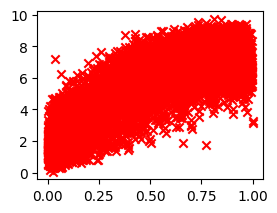

In [24]:
plt.subplot(2,2,1)
plt.scatter(x_train['energy'],y_train,marker='x', c='r')


In [26]:
def compute_cost(x,y,w,b):
    m = x.shape[0]
    total_cost = 0
    cost = 0
    for i in range(m):
        f_wb = w* x[i] + b
        cost += (f_wb - y[i])**2
    total_cost = cost/ (2*m)    
    return total_cost

In [29]:
initial_w = 2
initial_b = 1
cost = compute_cost(x_train['energy'], y_train, initial_w, initial_b)
print(type(cost))
print("Cost at w = {}, b = {} is {}".format(initial_w, initial_b, cost))

<class 'numpy.float64'>
Cost at w = 2, b = 1 is 9.258770198130733


now giving initial values of w and b as according to the gradient decent the w and b values are adjusted 

In [30]:
def compute_gradient(x,y,w,b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        f_wb = w* x[i] + b
        dj_dw +=(f_wb-y[i])*x[i]
        dj_db += (f_wb - y[i])
    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db

In [32]:
initial_w = 0
initial_b = 0
dj_dw, dj_db = compute_gradient(x_train['energy'], y_train, initial_w, initial_b)
print("Gradient at w = {}, b = {} is dj_dw = {}, dj_db = {}".format(initial_w, initial_b, dj_dw, dj_db))

Gradient at w = 0, b = 0 is dj_dw = -3.9287402964176255, dj_db = -6.146214621462138


In [33]:
test_w = 0.2
test_b = 0.2
tmp_dj_dw, tmp_dj_db = compute_gradient(x_train['energy'], y_train, test_w, test_b)
print("Gradient at w = {}, b = {} is dj_dw = {}, dj_db = {}".format(test_w, test_b, tmp_dj_dw, tmp_dj_db))

Gradient at w = 0.2, b = 0.2 is dj_dw = -3.7349987486741805, dj_db = -5.831729876207638


In [40]:
import copy
import math
def gradient_descent(x, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    m = len(x)
    J_history = []
    w_history = []
    w = copy.deepcopy(w_in)
    b = b_in
    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x, y, w, b )  
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               
        if i<100000:
            cost =  cost_function(x, y, w, b)
            J_history.append(cost)
        if i% math.ceil(num_iters/10) == 0:
            w_history.append(w)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
        
    return w, b, J_history, w_history

In [41]:

initial_w = 0.
initial_b = 0.
iterations = 1500
alpha = 0.01
x_train = df['energy'].values
y_train = df['user_preference'].values
w,b,_,_ = gradient_descent(x_train ,y_train, initial_w, initial_b, compute_cost, compute_gradient, alpha, iterations)
print("w,b found by gradient descent:", w, b)

Iteration    0: Cost    20.30   
Iteration  150: Cost     1.34   
Iteration  300: Cost     0.97   
Iteration  450: Cost     0.93   
Iteration  600: Cost     0.90   
Iteration  750: Cost     0.87   
Iteration  900: Cost     0.85   
Iteration 1050: Cost     0.83   
Iteration 1200: Cost     0.81   
Iteration 1350: Cost     0.80   
w,b found by gradient descent: 4.5019152237056295 3.6147672165108307


In [42]:
m = x_train.shape[0]
predicted = np.zeros(m)

for i in range(m):
    predicted[i] = w * x_train[i] + b

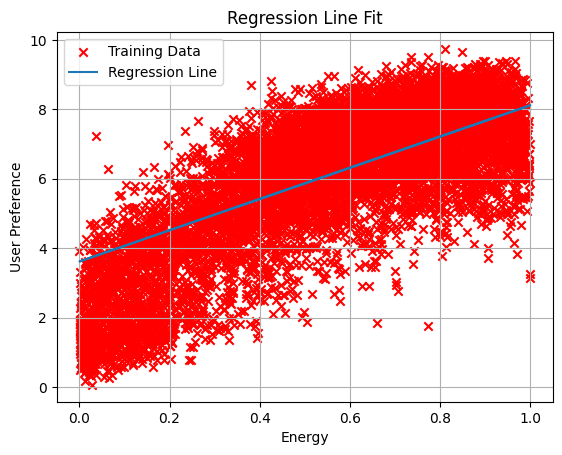

In [46]:
# Scatter plot of your training data
plt.scatter(x_train, y_train, marker='x', c='r', label='Training Data')

# Plot the regression line
plt.plot(x_train, w * x_train + b, label='Regression Line')

plt.xlabel('Energy')  # or your x feature name
plt.ylabel('User Preference')
plt.title('Regression Line Fit')
plt.legend()
plt.grid(True)
plt.show()

In [50]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Scatter3d(
    x=df['energy'],
    y=df['valence'],
    z=df['user_preference'],
    mode='markers',
    marker=dict(
        size=5,
        color=df['user_preference'],   # color mapped to user preference
        colorscale='Viridis',          # nice colorscale
        opacity=0.8
    )
)])

fig.update_layout(
    title='3D Scatter Plot - Energy, Valence vs User Preference',
    scene=dict(
        xaxis_title='Energy',
        yaxis_title='Valence',
        zaxis_title='User Preference'
    )
)

fig.show()

In [ ]:
import numpy as np
import plotly.graph_objs as go
import cufflinks as cf

cf.go_offline()
w1 = 4.5
w2 = 3.2
b = 3.61

x = df['energy']
y = df['valence']
z = df['user_preference']

xx, yy = np.meshgrid(
    np.linspace(x.min(), x.max(), 30),
    np.linspace(y.min(), y.max(), 30)
)

zz = w1 * xx + w2 * yy + b

scatter = go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    marker=dict(
        size=6,
        color='orange',
        opacity=0.9,
        line=dict(color='darkorange', width=1)
    ),
    name='Data Points'
)

surface = go.Surface(
    x=xx, y=yy, z=zz,
    colorscale='Plasma',
    opacity=0.8,
    showscale=True,
    lighting=dict(ambient=0.5, diffuse=0.8, specular=0.5, roughness=0.9, fresnel=0.2),
    lightposition=dict(x=100, y=200, z=0),
    name='Regression Hyperplane'
)

fig = go.Figure(data=[scatter, surface])

fig.update_layout(
    title='3D Scatter Plot with Regression Hyperplane',
    scene=dict(
        xaxis_title='Energy',
        yaxis_title='Valence',
        zaxis_title='User Preference',
        xaxis=dict(backgroundcolor="rgb(230, 230,230)"),
        yaxis=dict(backgroundcolor="rgb(230, 230,230)"),
        zaxis=dict(backgroundcolor="rgb(230, 230,230)")
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

Our model looks at features like energy and valence of songs you have listened to and liked in the past. It learns your taste and creates a kind of decision boundary (hyperplane) in this 3D space. When a new song comes along, it predicts your preference score based on these features. This helps us distinguish which songs you will probably like or dislike - so we can recommend better music to you and improve your experience

In [ ]:
w_energy = 4.5
w_valence = 3.6
b = 3.6
def predict_user_preference(energy, valence):
    preference = w_energy * energy + w_valence * valence + b
    return preference
new_song_energy = 0.7
new_song_valence = 0.4
predicted_preference = predict_user_preference(new_song_energy, new_song_valence)
print(f"Predicted user preference for the new song: {predicted_preference:.2f}")
if predicted_preference > 5:
    print("AI prediction: User will likely enjoy this song.")
else:
    print("AI prediction: User might not prefer this song.")

Predicted user preference for the new song: 8.19
AI prediction: User will likely enjoy this song.
